In [20]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
from tqdm.notebook import tqdm
import scipy
import sklearn
import random 
cwd = Path('.')

In [21]:
random.seed(0)
data_path = cwd / 'data' / '2025_LoL_esports_match_data_from_OraclesElixir_imputated.csv'
data = pd.read_csv(data_path,index_col=0)
data_len = int(len(data) * 10 / 12)
print(f"matches: {int(data_len/10)}, made up of {data_len} player performances")
print(f"number of columns: {data.shape[1]}")
print(f"percentage categorical variables: {data.select_dtypes(include='object').shape[1] / data.shape[1] * 100:.2f}%")

C:\Users\dwarf\AppData\Local\Temp\ipykernel_4088\1012244486.py:3: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv(data_path,index_col=0)


matches: 10053, made up of 100530 player performances
number of columns: 165
percentage categorical variables: 13.94%


In [22]:
data = data.drop(data[data["position"] == "team"].index) 

In [23]:
#dropping columns drops international event data as it has a lot of missing data, but we do not need that data for this, so do not drop data
"""
from utils.transform import smart_drop_na
# drop columns with more than a given percentage of missing values
data = smart_drop_na(
    data,
    column_percentage_threshold=0.20,
    row_percentage_threshold=0
)
"""
missing_playerids = data[data["playerid"].isna()]
missing_players = missing_playerids["playername"].unique()
gameids = missing_playerids["gameid"].unique()
print(f"there are {len(missing_playerids)} player performances without an associated playerid and {len(missing_players)} unique player names associated with those performances, we remove all of these")
data = data[~data["gameid"].isin(gameids)]



there are 1803 player performances without an associated playerid and 237 unique player names associated with those performances, we remove all of these


In [24]:
uniq_player_ids = data["playerid"].unique()
playerid_to_adj_index = dict(zip(uniq_player_ids, range(len(uniq_player_ids))))
adj_matrix = np.zeros((len(uniq_player_ids), len(uniq_player_ids)))


In [25]:
for i in tqdm(range(0, len(data), 10)):
    player_ids = []
    for j in range(10):
        player_ids.append(data.iloc[i + j]["playerid"])
    
    for p1 in player_ids:
        for p2 in player_ids:
            adj_matrix[playerid_to_adj_index[p1], playerid_to_adj_index[p2]] = 1

  0%|          | 0/9691 [00:00<?, ?it/s]

In [26]:
data

,gameid,datacompleteness,url,league,year,split,playoffs,date,game,patch,...,opp_csat25,golddiffat25,xpdiffat25,csdiffat25,killsat25,assistsat25,deathsat25,opp_killsat25,opp_assistsat25,opp_deathsat25
0,LOLTMNT03_179647,complete,NaN,LFL2,2025,Winter,0,2025-01-11 11:11:24,1,15.01,...,200.0,224.0,-1.0,17.0,1.0,1.0,2.0,2.0,4.0,2.0
1,LOLTMNT03_179647,complete,NaN,LFL2,2025,Winter,0,2025-01-11 11:11:24,1,15.01,...,157.0,-2363.0,-1444.0,-18.0,0.0,1.0,2.0,1.0,7.0,0.0
2,LOLTMNT03_179647,complete,NaN,LFL2,2025,Winter,0,2025-01-11 11:11:24,1,15.01,...,241.0,-1552.0,-2465.0,-41.0,1.0,0.0,2.0,1.0,5.0,1.0
3,LOLTMNT03_179647,complete,NaN,LFL2,2025,Winter,0,2025-01-11 11:11:24,1,15.01,...,257.0,-2613.0,-1156.0,-6.0,1.0,1.0,2.0,6.0,2.0,0.0
4,LOLTMNT03_179647,complete,NaN,LFL2,2025,Winter,0,2025-01-11 11:11:24,1,15.01,...,20.0,-662.0,-734.0,18.0,0.0,2.0,2.0,0.0,8.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
120629,LOLTMNT03_332179,complete,NaN,DCup,2025,NaN,0,2025-12-29 10:52:27,3,15.24,...,188.0,1763.0,3518.0,31.0,2.0,5.0,2.0,0.0,5.0,3.0
120630,LOLTMNT03_332179,complete,NaN,DCup,2025,NaN,0,2025-12-29 10:52:27,3,15.24,...,144.0,1750.0,2364.0,45.0,2.0,8.0,1.0,1.0,4.0,3.0
120631,LOLTMNT03_332179,complete,NaN,DCup,2025,NaN,0,2025-12-29 10:52:27,3,15.24,...,224.0,-125.0,-500.0,-32.0,8.0,5.0,2.0,4.0,4.0,1.0
120632,LOLTMNT03_332179,complete,NaN,DCup,2025,NaN,0,2025-12-29 10:52:27,3,15.24,...,221.0,-541.0,513.0,5.0,0.0,7.0,2.0,2.0,4.0,2.0


In [27]:
for j in range(adj_matrix.shape[0]):
    adj_matrix[j,j] = 0

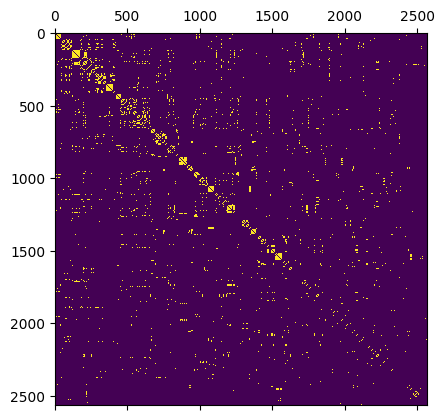

In [28]:
plt.matshow(adj_matrix)

In [29]:
z = sklearn.cluster.spectral_clustering(adj_matrix, n_clusters=5)

In [30]:
league_to_region_dict = {"LFL2":"EU", 
"LPL": "CN", 
"LCKC": "KR", 
"LVP SL": "EU", 
"LCK" : "KR", 
"NLC": "EU", 
"LCP": "APAC",
"LEC": "EU",
"HLL": "EU",
"PRM": "EU", 
"LFL": "EU",
"LIT": "EU",
"TCL": "EU",
"HW": "EU",
"LJL": "JP",
"LTA S": "LAT",
"LTA N": "NA",
"RL": "EU",
"NEXO": "EU", 
"CD": "LAT",
"EBL": "EU",
"PCS": "APAC", 
"ROL": "EU",
"LPLOL": "EU", 
"AL": "EU",
"LTA": "NA",
"VCS": "APAC",
"FST": "INT",
"EM": "EU",
"LRS": "LAT",
"LRN": "LAT",
"NACL": "NA", 
"LAS": "KR",
"HC": "EU", 
"PRMP": "EU",
"HM": "EU", 
"CT": "EU",
"Asia Master": "INT",
"MSI": "INT",
"EWC": "INT",
"WLDs": "INT",
"ASI": "INT",
"IC": "EU",
"KeSPA": "KR",
"DCup": "CN"
}

In [31]:
regions = dict.fromkeys(set(league_to_region_dict.values()), 0)
regions

{'KR': 0, 'LAT': 0, 'APAC': 0, 'INT': 0, 'NA': 0, 'CN': 0, 'EU': 0, 'JP': 0}

In [32]:
region_names = ["EU","JP","APAC","CN","LAT","KR","NA","INT"]

In [33]:
for i in range(5):
    region_count = dict.fromkeys(set(league_to_region_dict.values()), 0)
    for playerid in uniq_player_ids[z == i]:
        leagues = data[data["playerid"] == playerid]["league"].unique()
        for league in leagues:
            region = league_to_region_dict[league]
            region_count[region] += 1
    print(i)
    print(region_count)
    print("__")


0
{'KR': 0, 'LAT': 2, 'APAC': 3, 'INT': 0, 'NA': 3, 'CN': 0, 'EU': 2008, 'JP': 0}
__
1
{'KR': 298, 'LAT': 37, 'APAC': 244, 'INT': 470, 'NA': 93, 'CN': 175, 'EU': 56, 'JP': 70}
__
2
{'KR': 0, 'LAT': 221, 'APAC': 0, 'INT': 0, 'NA': 4, 'CN': 0, 'EU': 0, 'JP': 0}
__
3
{'KR': 0, 'LAT': 0, 'APAC': 0, 'INT': 0, 'NA': 0, 'CN': 0, 'EU': 216, 'JP': 0}
__
4
{'KR': 0, 'LAT': 103, 'APAC': 0, 'INT': 0, 'NA': 124, 'CN': 0, 'EU': 1, 'JP': 0}
__


In [37]:
colors = ["#f9c80e", "#f86624", "#ea3546", "#662e9b", "#43bccd"]

color_labels = [colors[x] for x in z]



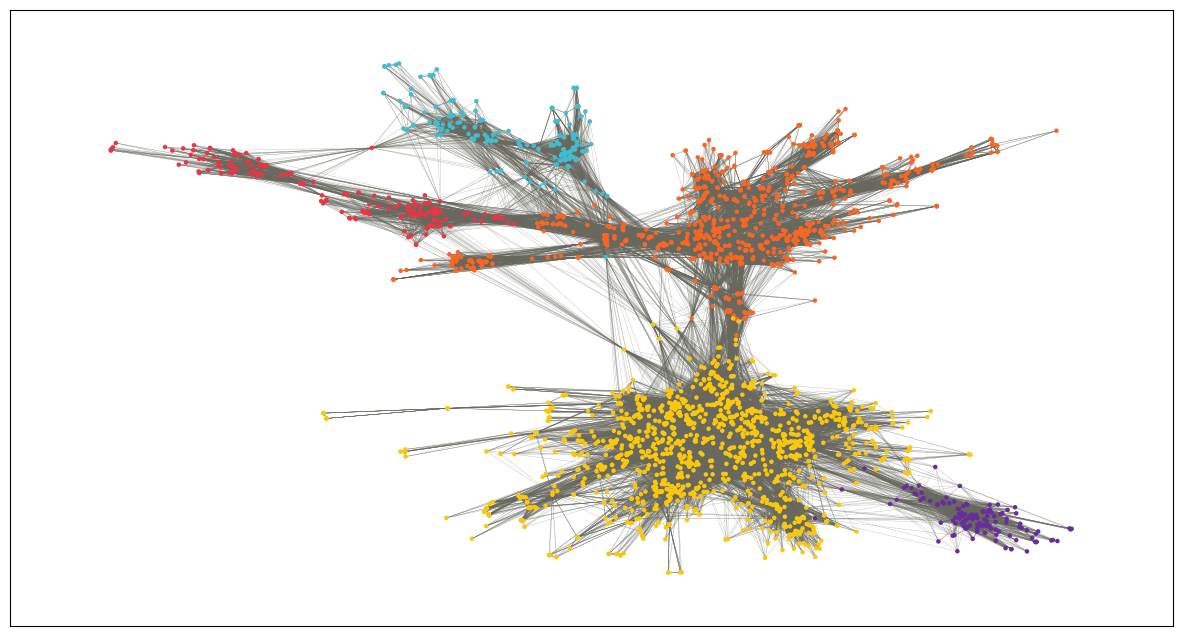

In [38]:
import networkx as nx
plt.figure(figsize=(15,8))
G = nx.from_numpy_array(adj_matrix)
layout = nx.spring_layout(G, seed=1)
nx.draw_networkx_nodes(G, layout, node_size=5, node_color=color_labels)
nx.draw_networkx_edges(G, layout, width=0.2, alpha=0.6, edge_color = "#68685e")

# Page Rank

In [ ]:
player_region = []
for playerid in uniq_player_ids:
    region_count = dict.fromkeys(set(league_to_region_dict.values()), 0)
    leagues = data[data["playerid"] == playerid]["league"].unique()
    for league in leagues:
        region = league_to_region_dict[league]
        region_count[region] += 1
    player_region.append(max(region_count, key=lambda key: region_count[key]))
    

In [39]:
page_ranked = nx.pagerank(G)

In [40]:
page_ranked_sorted = dict(sorted(page_ranked.items(), key=lambda item: item[1],reverse=True))

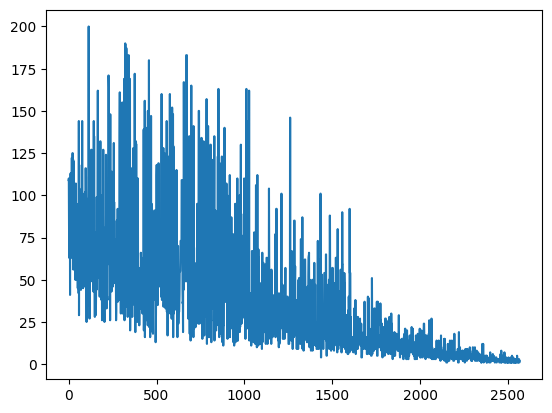

In [41]:
pr_keys = page_ranked_sorted.keys()
pr_array = []
for val in pr_keys:
    id = list(playerid_to_adj_index.keys())[val]
    pr_id_data = data.loc[data['playerid'] == id]
    pr_array.append(pr_id_data.shape[0])
plt.plot(pr_array)

We see that there is a strong correlation between the number of matches a player is invovled in and their ranking on using pagerank, which is unsurprising as we would assume that players who are highly ranked using pagerank purely based on if they have played eachother or not, are those who have played against the most players, weighted more towards those who are high in pagerank.

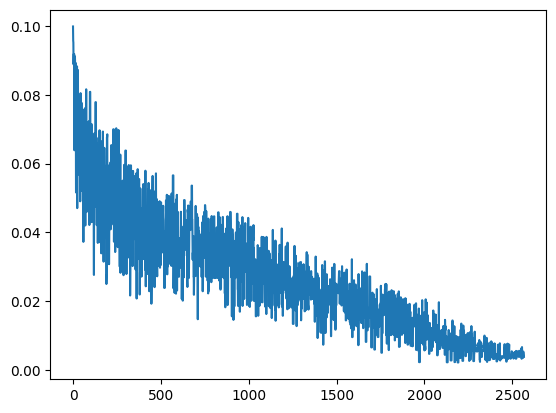

In [42]:
pr_keys = page_ranked_sorted.keys()
pr_array = []
for val in pr_keys:
    sum_val = 0
    adj_vect = adj_matrix[val]
    for i in range(len(adj_vect)):
        if adj_vect [i]== 1:
            sum_val += page_ranked_sorted [i]
    pr_array.append(sum_val)
plt.plot(pr_array)

By summing the pagerank of all opponents at each stage we see an even more clear correlation though still not perfect so lets take a look at some means for the top 50 vs the bottom 50 in page rank to see if something else is being picked up 

In [43]:
pr_keys_list = list(pr_keys)
top_50_player_ids = [list(playerid_to_adj_index.keys())[val] for val in pr_keys_list[:50]]

In [44]:
numeric_cols = data.select_dtypes(include='number').columns

In [45]:
data[numeric_cols] = (data[numeric_cols] - data[numeric_cols].min()) / (data[numeric_cols].max() - data[numeric_cols].min())

In [46]:
mean_values_top_50 = data[data['playerid'].isin(top_50_player_ids)][numeric_cols].mean()
print(mean_values_top_50)

year               0.016678
playoffs           0.296271
game               0.212879
patch              0.427904
participantid      0.527939
                     ...   
assistsat25        0.162176
deathsat25         0.162314
opp_killsat25      0.110081
opp_assistsat25    0.137873
opp_deathsat25     0.191217
Length: 142, dtype: float64


In [47]:
bot_50_player_ids = [list(playerid_to_adj_index.keys())[val] for val in pr_keys_list[len(pr_keys_list)-50:]]

In [48]:
mean_values_bot_50 = data[data['playerid'].isin(bot_50_player_ids)][numeric_cols].mean()
print(mean_values_bot_50)

year               0.047619
playoffs           0.295238
game               0.204762
patch              0.460455
participantid      0.477249
                     ...   
assistsat25        0.156803
deathsat25         0.227041
opp_killsat25      0.143991
opp_assistsat25    0.187075
opp_deathsat25     0.175170
Length: 142, dtype: float64


In [49]:
diff_50 = mean_values_top_50-mean_values_bot_50
diff_50.max()

0.35549819649889136

In [50]:
diff_50.idxmax()

'result'

Interestingly the main difference between the mean values of the top 50, and bottom 50 is the result. However, this is likely due to the very small amount of matches for the lower page rank value teams, as assuming no wins in those few matches (typically 3-4) for the absolute bottom, then this is likely the reason why we can see this difference. Though it also points to a notion that typically worse teams play fewer matches as they play in smaller tournaments, and even then are more likely to lose to better small teams

<AxesSubplot: >

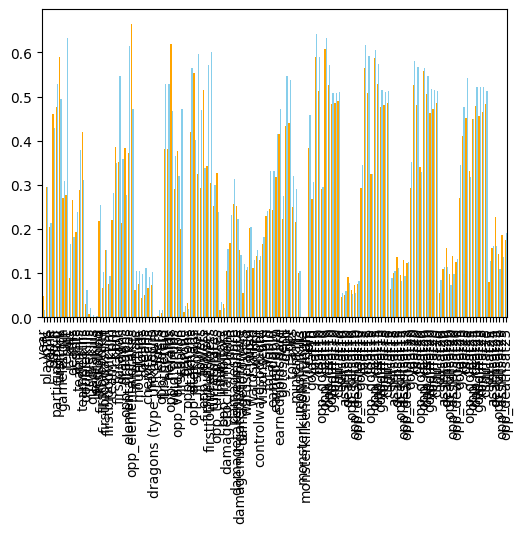

In [51]:
plt.figure(figsize=(6,4))

mean_values_top_50.plot(kind='bar', color='skyblue', position=0, width=0.4, label='Top 50')

mean_values_bot_50.plot(kind='bar', color='orange', position=1, width=0.4, label='Bottom 50')

While this is not a very clear chart, it does show that there is some large differences between the top and bottom 50 players, which we discussed above as to why we might see these differences

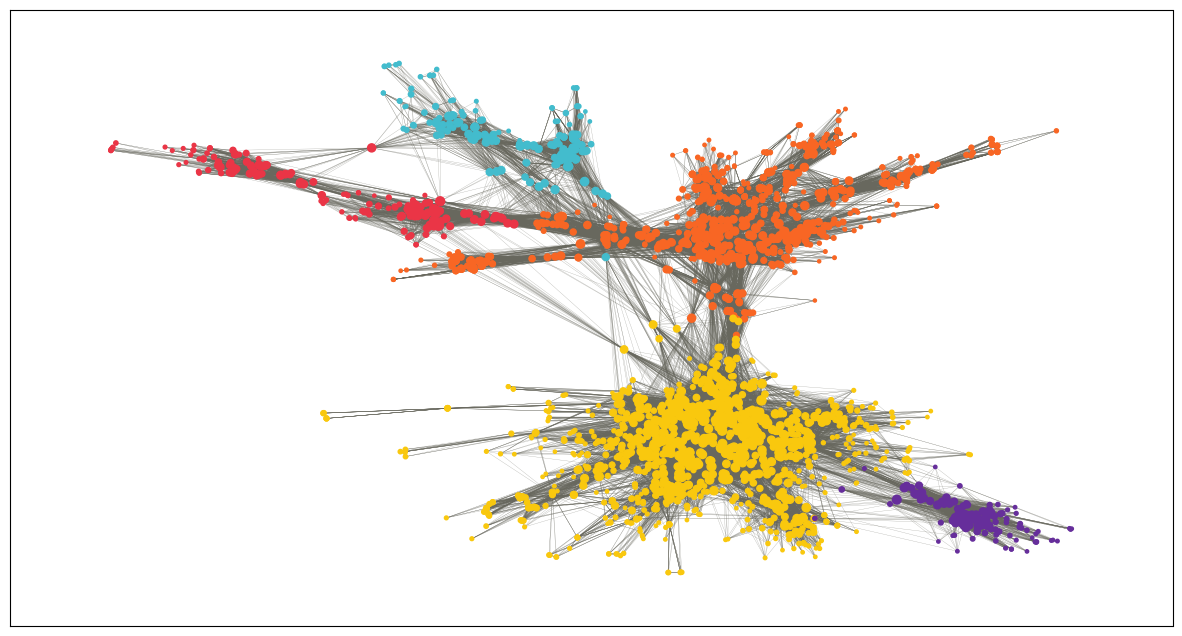

In [52]:
plt.figure(figsize=(15,8))
node_sizes = [50000 * page_ranked[node] for node in G.nodes()]
nx.draw_networkx_nodes(G, layout, node_size=node_sizes, node_color=color_labels)
nx.draw_networkx_edges(G, layout, width=0.2, alpha=0.6, edge_color = "#68685e")

If we plot as before but now scale each node by the its value in our page ranking we see unsurpisingly that the more connected nodes are often larger

In [53]:
page_ranked_sorted

{456: 0.0010555915051630113,
 453: 0.0009960921368608,
 1114: 0.000975814835675167,
 995: 0.0009658759775636886,
 194: 0.0009650951099559316,
 195: 0.0009650951099559316,
 196: 0.0009650951099559316,
 198: 0.0009650951099559316,
 217: 0.0009627469926214831,
 197: 0.000941795628109293,
 968: 0.0009391942083487988,
 1213: 0.0009051470873872642,
 120: 0.0008828994137691214,
 969: 0.0008748682996666446,
 525: 0.0008685884297957108,
 1277: 0.0008664747579873784,
 579: 0.000861081422029027,
 1078: 0.0008478139350099573,
 1079: 0.0008478139350099573,
 1081: 0.0008478139350099573,
 1082: 0.0008478139350099573,
 562: 0.000844477753987699,
 160: 0.0008383291329408437,
 161: 0.0008383291329408437,
 926: 0.0008374630112910272,
 446: 0.0008301576191108302,
 164: 0.0008271808678452584,
 978: 0.0008208179485710086,
 163: 0.0008168036458408852,
 1216: 0.000816329988048139,
 1007: 0.0008158915600325136,
 32: 0.0008092999437491176,
 1164: 0.0008087392441412341,
 454: 0.0008066019034265254,
 457: 0.00080

In [54]:
playerid = list(playerid_to_adj_index.keys())[456]
pr_id_data = data.loc[data['playerid'] == playerid]
pr_id_data

,gameid,datacompleteness,url,league,year,split,playoffs,date,game,patch,...,opp_csat25,golddiffat25,xpdiffat25,csdiffat25,killsat25,assistsat25,deathsat25,opp_killsat25,opp_assistsat25,opp_deathsat25
1988,LOLTMNT01_190317,complete,NaN,HLL,0.0,Winter,0.0,2025-01-21 16:53:53,0.00,0.000000,...,0.740864,0.640577,0.568179,0.476087,0.277778,0.366667,0.083333,0.055556,0.000000,0.166667
2223,LOLTMNT01_190394,complete,NaN,HLL,0.0,Winter,0.0,2025-01-22 15:10:37,0.00,0.000000,...,0.837209,0.550130,0.551988,0.463043,0.055556,0.066667,0.083333,0.111111,0.033333,0.083333
2799,LOLTMNT01_189529,complete,NaN,HLL,0.0,Winter,0.0,2025-01-23 17:01:27,0.00,0.000000,...,0.767442,0.608950,0.481110,0.456522,0.444444,0.100000,0.083333,0.111111,0.033333,0.333333
4796,LOLTMNT01_194511,complete,NaN,HLL,0.0,Winter,0.0,2025-01-28 15:27:24,0.00,0.043478,...,0.691030,0.548297,0.522084,0.517391,0.111111,0.133333,0.083333,0.055556,0.133333,0.083333
5139,LOLTMNT01_194983,complete,NaN,HLL,0.0,Winter,0.0,2025-01-29 16:36:28,0.00,0.043478,...,0.734219,0.634784,0.656460,0.460870,0.777778,0.400000,0.083333,0.333333,0.066667,0.416667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
114080,LOLTMNT06_143465,complete,NaN,EM,0.0,Summer,0.0,2025-10-07 13:00:28,0.00,0.782609,...,0.797342,0.461693,0.464423,0.486957,0.111111,0.166667,0.083333,0.222222,0.100000,0.000000
114152,LOLTMNT06_144408,complete,NaN,EM,0.0,Summer,0.0,2025-10-07 13:55:00,0.25,0.782609,...,0.760797,0.534169,0.416621,0.547826,0.222222,0.066667,0.250000,0.277778,0.166667,0.166667
114519,LOLTMNT06_143495,complete,NaN,EM,0.0,Summer,0.0,2025-10-08 15:01:37,0.00,0.782609,...,0.697674,0.523883,0.472023,0.521739,0.111111,0.166667,0.250000,0.166667,0.033333,0.166667
114555,LOLTMNT06_144441,complete,NaN,EM,0.0,Summer,0.0,2025-10-08 16:05:53,0.25,0.782609,...,0.893688,0.480314,0.559808,0.436957,0.000000,0.033333,0.000000,0.000000,0.066667,0.083333


This gives us that the most important player in terms of connections is Axelent from Team Phantasma, which is not exactly what we were expecting

Lets try and use personalized page rank instead, where we start by having our personalization vector exclusively target one player

In [55]:
playerid = list(playerid_to_adj_index.keys())[0]
region_count_p0 = dict.fromkeys(set(league_to_region_dict.values()), 0)
leagues = data[data["playerid"] == playerid]["league"].unique()
for league in leagues:
    region = league_to_region_dict[league]
    region_count_p0[region] += 1
region_count_p0

{'KR': 0, 'LAT': 0, 'APAC': 0, 'INT': 0, 'NA': 0, 'CN': 0, 'EU': 1, 'JP': 0}

In [56]:
personlization = {node:0 for node in G.nodes()}
personlization[0]=1
ppreu = nx.pagerank(G,personalization=personlization)
thresh = 0.0001
for k, v in ppreu.items():
    if v < thresh:
        ppreu[k] = 0


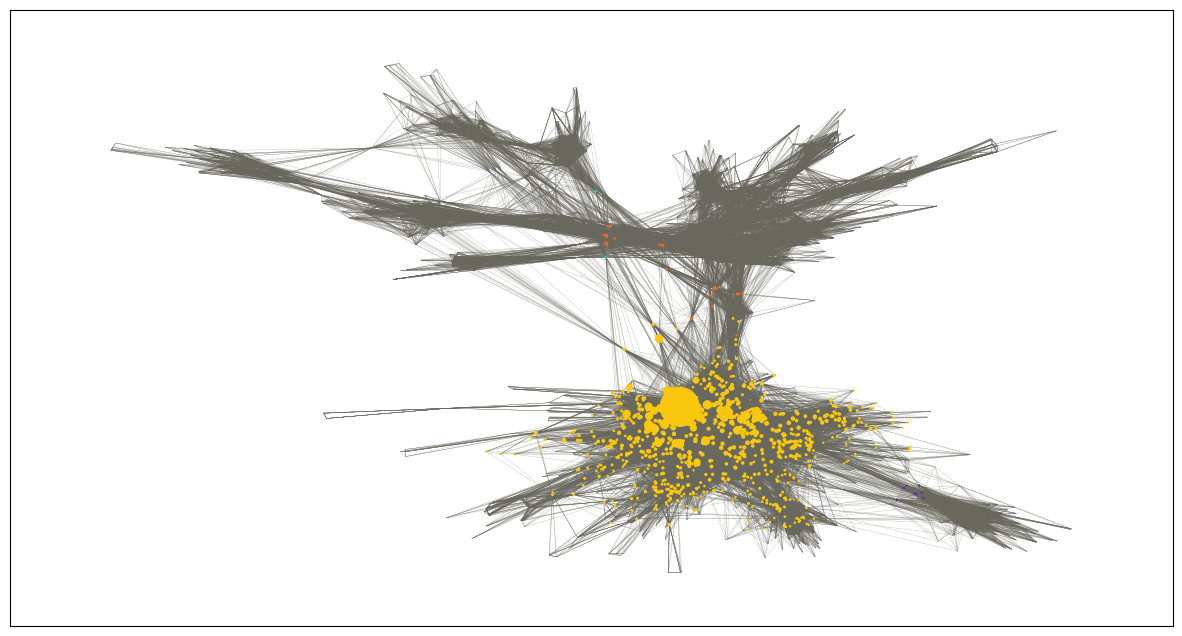

In [57]:
plt.figure(figsize=(15,8))
node_sizes = [5000 * ppreu[node] for node in G.nodes()]
nx.draw_networkx_nodes(G, layout, node_size=node_sizes, node_color=color_labels)
nx.draw_networkx_edges(G, layout, width=0.2, alpha=0.6, edge_color = "#68685e")

This gives us a pretty decent community around this exact point, so if we looked at only a few players from each region we would be able to find quite a few who are in the same community as such we can use this as a form of community detection assuming we know the region for just a few players.

In [58]:
indices_eu = [i for i, x in enumerate(player_region) if x == "EU"]
indices_jp = [i for i, x in enumerate(player_region) if x == "JP"]
indices_apac = [i for i, x in enumerate(player_region) if x == "APAC"]
indices_cn = [i for i, x in enumerate(player_region) if x == "CN"]
indices_lat = [i for i, x in enumerate(player_region) if x == "LAT"]
indices_kr = [i for i, x in enumerate(player_region) if x == "KR"]
indices_na = [i for i, x in enumerate(player_region) if x == "NA"]
indices_int = [i for i, x in enumerate(player_region) if x == "INT"]

indices = [indices_eu,indices_jp,indices_apac,indices_apac,indices_cn,indices_lat,indices_kr,indices_na,indices_int]

In [59]:

random_eu = random.sample(indices_eu, 3)
random_jp = random.sample(indices_jp, 3)
random_apac = random.sample(indices_apac, 3)
random_cn = random.sample(indices_cn, 3)
random_lat = random.sample(indices_lat, 3)
random_kr = random.sample(indices_kr, 3)
random_na = random.sample(indices_na, 3)
random_int = random.sample(indices_int, 3)

randoms = [random_eu,random_jp,random_apac,random_cn,random_lat,random_kr,random_na,random_int]

In [60]:
personlization = {node:0 for node in G.nodes()}
for val in random_eu:
    personlization[val]=1/len(random_eu)
ppreu_2 = nx.pagerank(G,personalization=personlization)
thresh = 0.0001
for k, v in ppreu_2.items():
    if v < thresh:
        ppreu_2[k] = 0



In [61]:
z_as_list = list(z)


In [62]:
prev_best_vals = [0]*(len(uniq_player_ids))
preds = [-1]*len(uniq_player_ids)
for i in range(len(region_names)):    
    personlization = {node:0 for node in G.nodes()}
    for val in randoms[i]:
        personlization[val]=1/len(randoms[i])
    ppr_ran = nx.pagerank(G,personalization=personlization)

    for val in ppr_ran:
        if ppr_ran[val]>=prev_best_vals[val]:
            preds[val]=region_names[i]
            prev_best_vals[val]=ppr_ran[val]
        



In [65]:
from utils import score
from sklearn.metrics import normalized_mutual_info_score
score.score_regions(preds,uniq_player_ids,data,normalized_mutual_info_score)

0.7769263561559481

In [66]:
spec_all_regions = sklearn.cluster.spectral_clustering(adj_matrix, n_clusters=len(region_names))

In [67]:
for i in range(len(region_names)):
    region_count = dict.fromkeys(set(league_to_region_dict.values()), 0)
    for playerid in uniq_player_ids[spec_all_regions == i]:
        leagues = data[data["playerid"] == playerid]["league"].unique()
        for league in leagues:
            region = league_to_region_dict[league]
            region_count[region] += 1
    print(i)
    print(region_count)
    print("__")

0
{'KR': 0, 'LAT': 2, 'APAC': 2, 'INT': 0, 'NA': 3, 'CN': 0, 'EU': 2001, 'JP': 0}
__
1
{'KR': 214, 'LAT': 13, 'APAC': 153, 'INT': 426, 'NA': 76, 'CN': 175, 'EU': 63, 'JP': 1}
__
2
{'KR': 0, 'LAT': 89, 'APAC': 0, 'INT': 0, 'NA': 0, 'CN': 0, 'EU': 0, 'JP': 0}
__
3
{'KR': 3, 'LAT': 0, 'APAC': 92, 'INT': 43, 'NA': 0, 'CN': 0, 'EU': 0, 'JP': 69}
__
4
{'KR': 0, 'LAT': 0, 'APAC': 0, 'INT': 0, 'NA': 0, 'CN': 0, 'EU': 216, 'JP': 0}
__
5
{'KR': 0, 'LAT': 105, 'APAC': 0, 'INT': 0, 'NA': 124, 'CN': 0, 'EU': 1, 'JP': 0}
__
6
{'KR': 1, 'LAT': 154, 'APAC': 0, 'INT': 0, 'NA': 21, 'CN': 0, 'EU': 0, 'JP': 0}
__
7
{'KR': 80, 'LAT': 0, 'APAC': 0, 'INT': 1, 'NA': 0, 'CN': 0, 'EU': 0, 'JP': 0}
__


In [70]:
spec_all_regions_cRegions = "EU", "INT", "LAT", "APAC", "EU", "NA", "LAT", "KR"
spec_all_regions_str = [0]*len(spec_all_regions)
for i in range(len(spec_all_regions)):
    spec_all_regions_str[i] = spec_all_regions_cRegions[spec_all_regions[i]]

In [72]:
score.score_regions(spec_all_regions_str,uniq_player_ids,data,normalized_mutual_info_score)

0.7169239756193964

We actually see a better score for the pagerank method, though not by much and considering that the pagerank method requires a small number of known communities, and it is also assuming that the communities that we would find would be exclusively within the region, which may not necesarrily be the case.

We can also try to use pagerank to find the best player by directing the adjacency matrix and giving each edge a weight corresponding to the number of wins vs that player. 

In [73]:
adj_matrix_directed = np.zeros((len(uniq_player_ids), len(uniq_player_ids)))

In [74]:
for i in tqdm(range(0, len(data), 10)):
    player_ids_win = []
    player_ids_loss = []
    for j in range(10):
        if data.iloc[i + j]["result"] == 1:
            player_ids_win.append(data.iloc[i + j]["playerid"])
        else:
            player_ids_loss.append(data.iloc[i + j]["playerid"])
    
    for p1 in player_ids_win:
        for p2 in player_ids_loss:
            adj_matrix_directed[playerid_to_adj_index[p1], playerid_to_adj_index[p2]] += 1

  0%|          | 0/9691 [00:00<?, ?it/s]

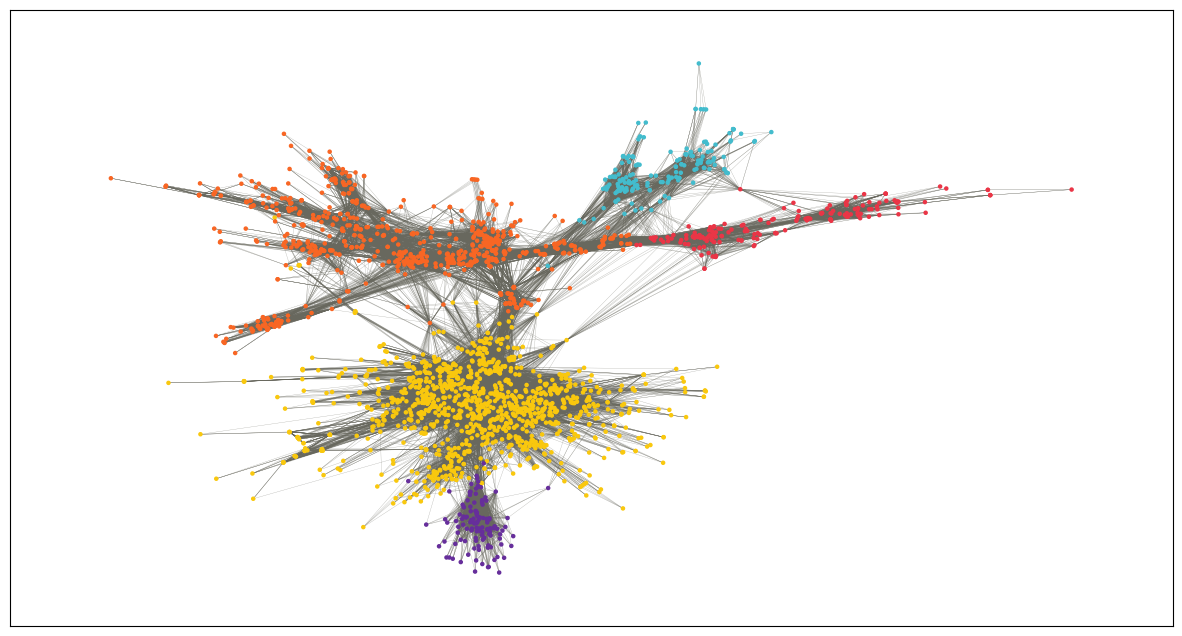

In [75]:
plt.figure(figsize=(15,8))
G_2 = nx.from_numpy_array(adj_matrix_directed)
layout_2 = nx.spring_layout(G_2, seed=1)
nx.draw_networkx_nodes(G_2, layout_2, node_size=5, node_color=color_labels)
nx.draw_networkx_edges(G_2, layout_2, width=0.2, alpha=0.6, edge_color = "#68685e")

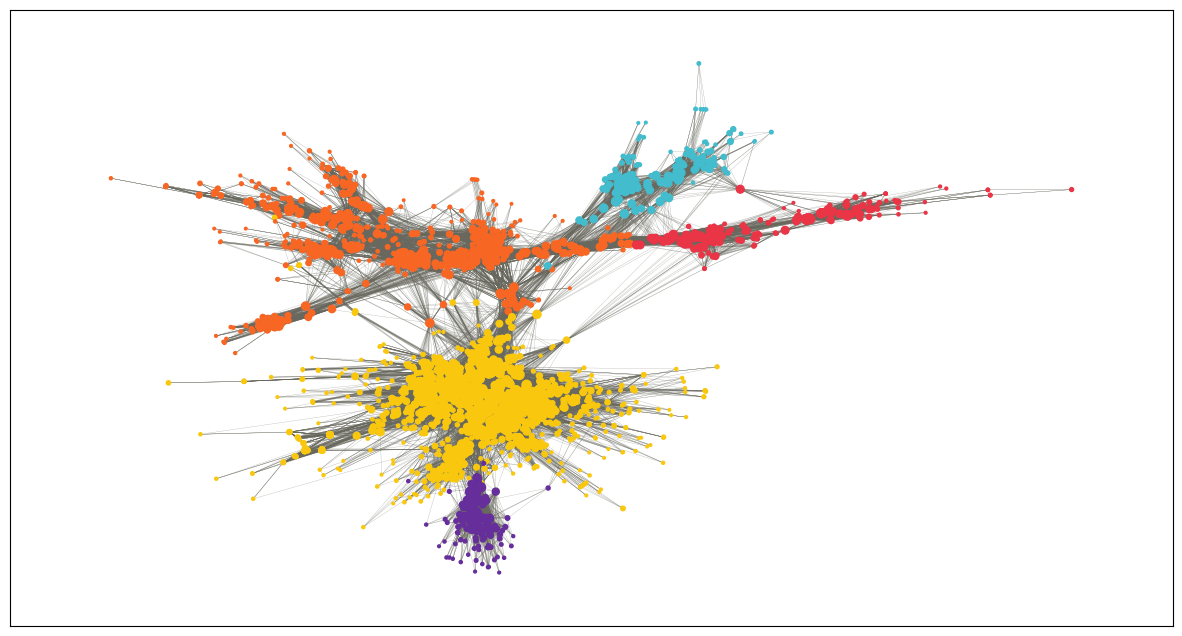

In [76]:
page_ranked_2 = nx.pagerank(G_2)
plt.figure(figsize=(15,8))
node_sizes = [50000 * page_ranked_2[node] for node in G_2.nodes()]
nx.draw_networkx_nodes(G_2, layout_2, node_size=node_sizes, node_color=color_labels)
nx.draw_networkx_edges(G_2, layout_2, width=0.2, alpha=0.6, edge_color = "#68685e")

In [77]:
pr_2_sorted = dict(sorted(page_ranked_2.items(), key=lambda item: item[1],reverse=True))

In [78]:
pr_2_sorted

{456: 0.001299873605764879,
 453: 0.0012460784369746922,
 194: 0.001165938787726179,
 195: 0.001165938787726179,
 196: 0.001165938787726179,
 198: 0.001165938787726179,
 454: 0.0011631308324596577,
 457: 0.0011631308324596577,
 1213: 0.0011587917633219848,
 1209: 0.0011554994273325224,
 1211: 0.0011554994273325224,
 197: 0.0011475185641967684,
 1078: 0.0011466926863296471,
 1079: 0.0011466926863296471,
 1081: 0.0011466926863296471,
 1082: 0.0011466926863296471,
 455: 0.001100463217480758,
 160: 0.0010979052290240009,
 161: 0.0010979052290240009,
 164: 0.0010850467979657068,
 163: 0.0010618484666429992,
 1173: 0.0010307440716189756,
 548: 0.0010267882200266064,
 550: 0.0010267882200266064,
 551: 0.0010267882200266064,
 626: 0.0009837305738589182,
 628: 0.0009837305738589182,
 629: 0.0009837305738589182,
 1196: 0.0009794174811894917,
 1007: 0.0009790019264812701,
 1198: 0.0009672475325235966,
 1390: 0.0009588945943139528,
 579: 0.0009517841816591841,
 552: 0.0009462120281285485,
 463: 0.

In [79]:
playerid = list(playerid_to_adj_index.keys())[456]
pr_id_data = data.loc[data['playerid'] == playerid]
pr_id_data

,gameid,datacompleteness,url,league,year,split,playoffs,date,game,patch,...,opp_csat25,golddiffat25,xpdiffat25,csdiffat25,killsat25,assistsat25,deathsat25,opp_killsat25,opp_assistsat25,opp_deathsat25
1988,LOLTMNT01_190317,complete,NaN,HLL,0.0,Winter,0.0,2025-01-21 16:53:53,0.00,0.000000,...,0.740864,0.640577,0.568179,0.476087,0.277778,0.366667,0.083333,0.055556,0.000000,0.166667
2223,LOLTMNT01_190394,complete,NaN,HLL,0.0,Winter,0.0,2025-01-22 15:10:37,0.00,0.000000,...,0.837209,0.550130,0.551988,0.463043,0.055556,0.066667,0.083333,0.111111,0.033333,0.083333
2799,LOLTMNT01_189529,complete,NaN,HLL,0.0,Winter,0.0,2025-01-23 17:01:27,0.00,0.000000,...,0.767442,0.608950,0.481110,0.456522,0.444444,0.100000,0.083333,0.111111,0.033333,0.333333
4796,LOLTMNT01_194511,complete,NaN,HLL,0.0,Winter,0.0,2025-01-28 15:27:24,0.00,0.043478,...,0.691030,0.548297,0.522084,0.517391,0.111111,0.133333,0.083333,0.055556,0.133333,0.083333
5139,LOLTMNT01_194983,complete,NaN,HLL,0.0,Winter,0.0,2025-01-29 16:36:28,0.00,0.043478,...,0.734219,0.634784,0.656460,0.460870,0.777778,0.400000,0.083333,0.333333,0.066667,0.416667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
114080,LOLTMNT06_143465,complete,NaN,EM,0.0,Summer,0.0,2025-10-07 13:00:28,0.00,0.782609,...,0.797342,0.461693,0.464423,0.486957,0.111111,0.166667,0.083333,0.222222,0.100000,0.000000
114152,LOLTMNT06_144408,complete,NaN,EM,0.0,Summer,0.0,2025-10-07 13:55:00,0.25,0.782609,...,0.760797,0.534169,0.416621,0.547826,0.222222,0.066667,0.250000,0.277778,0.166667,0.166667
114519,LOLTMNT06_143495,complete,NaN,EM,0.0,Summer,0.0,2025-10-08 15:01:37,0.00,0.782609,...,0.697674,0.523883,0.472023,0.521739,0.111111,0.166667,0.250000,0.166667,0.033333,0.166667
114555,LOLTMNT06_144441,complete,NaN,EM,0.0,Summer,0.0,2025-10-08 16:05:53,0.25,0.782609,...,0.893688,0.480314,0.559808,0.436957,0.000000,0.033333,0.000000,0.000000,0.066667,0.083333


Gives us axelent from team Phantasma, which does not seem right 

In [80]:
pr_2_sorted_rev = dict(sorted(page_ranked_2.items(), key=lambda item: item[1]))
pr_2_sorted_rev

{2531: 6.653081164800575e-05,
 2214: 6.710188362548277e-05,
 1241: 6.75131489758373e-05,
 2549: 7.017530801919323e-05,
 2213: 7.239185431388414e-05,
 1990: 7.269503338444176e-05,
 2357: 7.338947345716083e-05,
 1751: 7.355905923464237e-05,
 1753: 7.355905923464237e-05,
 1754: 7.355905923464237e-05,
 1755: 7.355905923464237e-05,
 1010: 7.357096544553922e-05,
 1251: 7.363883611952412e-05,
 1981: 7.369864132497786e-05,
 1722: 7.373618480919041e-05,
 1186: 7.37386717926111e-05,
 1188: 7.37386717926111e-05,
 1111: 7.401839216881905e-05,
 2403: 7.434029453508504e-05,
 1795: 7.438923931359758e-05,
 1056: 7.464313683347993e-05,
 1670: 7.492647409327395e-05,
 1671: 7.492647409327395e-05,
 1672: 7.492647409327395e-05,
 1673: 7.492647409327395e-05,
 1674: 7.492647409327395e-05,
 2182: 7.50214950265394e-05,
 2259: 7.513160100143068e-05,
 2263: 7.513160100143068e-05,
 1891: 7.524521078171762e-05,
 1393: 7.571012605331456e-05,
 1394: 7.571012605331456e-05,
 1395: 7.571012605331456e-05,
 1918: 7.64279

In [81]:
playerid = list(playerid_to_adj_index.keys())[2531]
pr_id_data = data.loc[data['playerid'] == playerid]
pr_id_data

,gameid,datacompleteness,url,league,year,split,playoffs,date,game,patch,...,opp_csat25,golddiffat25,xpdiffat25,csdiffat25,killsat25,assistsat25,deathsat25,opp_killsat25,opp_assistsat25,opp_deathsat25
113373,LOLTMNT03_304831,complete,NaN,Asia Master,0.0,NaN,0.0,2025-10-06 09:59:28,0.00,0.782609,...,0.093023,0.460806,0.433418,0.489130,0.0,0.300000,0.416667,0.055556,0.400000,0.166667
113404,LOLTMNT03_304839,complete,NaN,Asia Master,0.0,NaN,0.0,2025-10-06 10:57:19,0.25,0.782609,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
113445,LOLTMNT03_304849,complete,NaN,Asia Master,0.0,NaN,0.0,2025-10-06 11:40:15,0.50,0.782609,...,0.089701,0.446855,0.477531,0.497826,0.0,0.233333,0.250000,0.055556,0.233333,0.000000


Gives Sirius from team Gen.G Global Academy

Overall this does not seem to work very well at identifing the best players as axelent is absolutely not one of the best players in this data set